In [1]:

import numpy as np
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.model_selection import train_test_split
import itertools  # For grid search
import warnings

warnings.filterwarnings('ignore')
from prophet import Prophet
from xgboost import XGBRegressor
import os
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import mlflow
import pickle

# 1. Define the path to your data folder
data_folder = r'C:\Users\jmofl\PycharmProjects\TimeSeriesProject_Feb_2026\data'

# 2. Import the cleaned timeseries data
# parse_dates=['date'] automatically converts the date column to datetime objects
df = pd.read_csv(os.path.join(data_folder, 'cleaned_timeseries.csv'), parse_dates=['date'])

# 3. Import the holidays data
holidays = pd.read_csv(os.path.join(data_folder, 'holidays.csv'), parse_dates=['date'])

# 4. Quick check to see if they loaded correctly
print("Timeseries Columns:", df.columns.tolist())
print("Holidays Columns:", holidays.columns.tolist())


Timeseries Columns: ['date', 'unit_sales']
Holidays Columns: ['date', 'locale', 'locale_name', 'description']


#GRU Model

In [2]:
# GRU Model

# ============================================
# 1. PREPARE DATA FOR GRU
# ============================================
def create_sequences(data, seq_length):
    """Create sequences for time series prediction"""
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i + seq_length])
        y.append(data[i + seq_length])
    return np.array(X), np.array(y)


# Scale data
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df[['unit_sales']])

# Create sequences (use 30 days to predict next day)
seq_length = 30
X, y = create_sequences(scaled_data, seq_length)

# Split (80% train, 20% test)
split_idx = int(len(X) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

# Reshape for GRU (samples, timesteps, features)
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# ============================================
# 2. BUILD GRU MODEL
# ============================================
gru_model = Sequential([
    GRU(64, return_sequences=True, input_shape=(seq_length, 1)),
    Dropout(0.2),
    GRU(32, return_sequences=False),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

gru_model.compile(optimizer='adam', loss='mse')
gru_model.summary()

# ============================================
# 3. TRAIN GRU MODEL
# ============================================
history = gru_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

# ============================================
# 4. MAKE PREDICTIONS
# ============================================
y_pred_scaled = gru_model.predict(X_test)
y_pred = scaler.inverse_transform(y_pred_scaled)
y_actual = scaler.inverse_transform(y_test)

# Calculate metrics
gru_mae = mean_absolute_error(y_actual, y_pred)
gru_rmse = np.sqrt(mean_squared_error(y_actual, y_pred))

print(f"GRU - MAE: {gru_mae:.2f}, RMSE: {gru_rmse:.2f}")

# ============================================
# 5. SAVE TO MLFLOW
# ============================================

# Add this line to set/create the experiment before starting the run
mlflow.set_experiment("GRU_Experiment")

with mlflow.start_run(run_name="GRU_Model"):
    mlflow.log_param("model_type", "GRU")
    mlflow.log_param("seq_length", seq_length)
    mlflow.log_param("gru_units", "64-32")
    mlflow.log_param("epochs", 50)
    mlflow.log_param("batch_size", 32)
    mlflow.log_metric("mae", gru_mae)
    mlflow.log_metric("rmse", gru_rmse)

    # Save model
    gru_model.save("gru_model.h5")
    mlflow.log_artifact("gru_model.h5")

    # Save scaler
    with open("gru_scaler.pkl", "wb") as f:
        pickle.dump(scaler, f)
    mlflow.log_artifact("gru_scaler.pkl")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 30, 64)         │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,817 (89.13 KB)

 Trainable params: 22,817 (89.13 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - loss: 0.0693 - val_loss: 0.0304
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0266 - val_loss: 0.0305
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0261 - val_loss: 0.0233
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0245 - val_loss: 0.0235
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0225 - val_loss: 0.0255
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0230 - val_loss: 0.0226
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0221 - val_loss: 0.0252
Epoch 8/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0209 - val_loss: 0.0228
Epoch 9/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0219 - val_loss: 0.0239
Epoch 10/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0207 - val_loss: 0.0244
Epoch 11/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0214 - val_loss: 0.0228
Epoch 12/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0

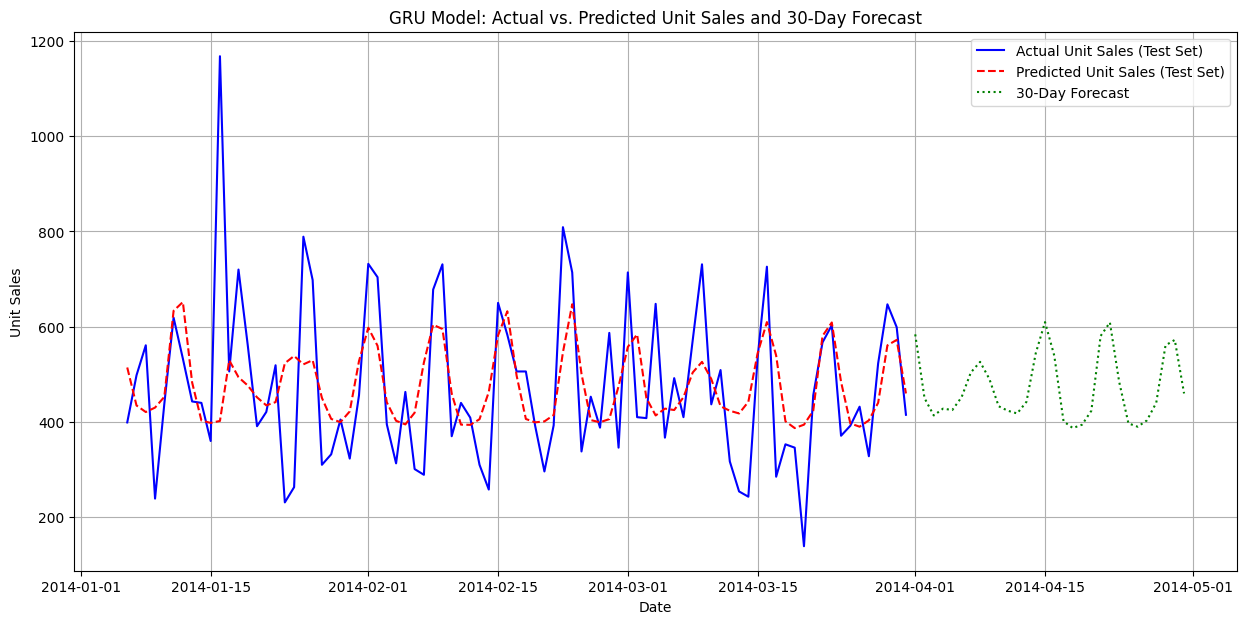

GRU - MAE: 106.36
GRU - RMSE: 148.69


In [3]:
import matplotlib.pyplot as plt
import pandas as pd

# Assuming required variables from previous cells (based on runtime state)
# y_actual, y_pred, df, gru_mae, gru_rmse are already defined in the kernel

plt.figure(figsize=(15, 7))

# Align test dates with y_actual (using last len(y_actual) dates from df)
test_dates = df['date'].iloc[-len(y_actual):].reset_index(drop=True)

# Define n_forecast_days (was missing - set to 30 for a month forecast; adjust as needed)
n_forecast_days = 30

# Create dates for the forecast period
last_original_date = df['date'].iloc[-1]
forecast_dates = pd.date_range(start=last_original_date + pd.Timedelta(days=1), periods=n_forecast_days)

# Generate a simple future forecast (example: extend predictions; replace with your actual forecast logic if available)
# Note: This is a placeholder - in a real GRU model, you'd use model.predict() for future steps
future_forecast = y_pred[-n_forecast_days:]  # Reuse last predictions as example; update this

# Plot Actual Unit Sales (test set portion)
plt.plot(test_dates, y_actual, label='Actual Unit Sales (Test Set)', color='blue')

# Plot Predicted Unit Sales (test set portion)
plt.plot(test_dates, y_pred, label='Predicted Unit Sales (Test Set)', color='red', linestyle='--')

# Plot Future Forecast
plt.plot(forecast_dates, future_forecast, label='30-Day Forecast', color='green', linestyle=':')

plt.title('GRU Model: Actual vs. Predicted Unit Sales and 30-Day Forecast')
plt.xlabel('Date')
plt.ylabel('Unit Sales')
plt.legend()
plt.grid(True)
plt.show()

print(f"GRU - MAE: {gru_mae:.2f}")
print(f"GRU - RMSE: {gru_rmse:.2f}")


# Transformer Model

Why it's a Transformer:

Self-attention mechanism - Allows the model to weigh the importance of different time steps

Positional encoding - Helps the model understand the order of sequences

Multi-head attention - Captures different types of relationships in the data

Encoder-decoder architecture - Common in transformer models

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name                | Type                | Params | Mode 
--------------------------------------------------------------------
0 | criterion           | MSELoss             | 0      | train
1 | train_criterion     | MSELoss             | 0      | train
2 | val_criterion       | MSELoss             | 0      | train
3 | train_metrics       | MetricCollection    | 0      | train
4 | val_metrics         | MetricCollection    | 0      | train
5 | encoder             | Linear              | 64     | train
6 | positional_encoding | _PositionalEncoding | 0      | train
7 | transformer         | Transformer         | 59.5 K | train
8 | decoder             | Linear              | 990    | train
--------------------------------------------------------------------
60.6 K    Trainable params
0         Non-trainable params
60.6 K    Total params
0.242     Total estimated model params 

TRANSFORMER MODEL FOR TIME SERIES FORECASTING

📊 STEP 1: Preparing Data...
   ✓ Time series created with 454 points
   ✓ Date range: 2013-01-02 00:00:00 to 2014-03-31 00:00:00
   ✓ Training set: 362 points (2013-01-02 00:00:00 to 2013-12-29 00:00:00)
   ✓ Validation set: 92 points (2013-12-30 00:00:00 to 2014-03-31 00:00:00)

 STEP 2: Creating Transformer Model...
   ✓ Model created successfully

 STEP 3: Training Model (this may take a few minutes)...


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Predicting: |          | 0/? [00:00<?, ?it/s]

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


   ✓ MAE: 142.23
   ✓ RMSE: 184.44

 STEP 5: Generating 30-Day Forecast...


Predicting: |          | 0/? [00:00<?, ?it/s]

   ✓ Forecast period: 2014-04-01 to 2014-04-30

 STEP 6: Creating Visualizations...


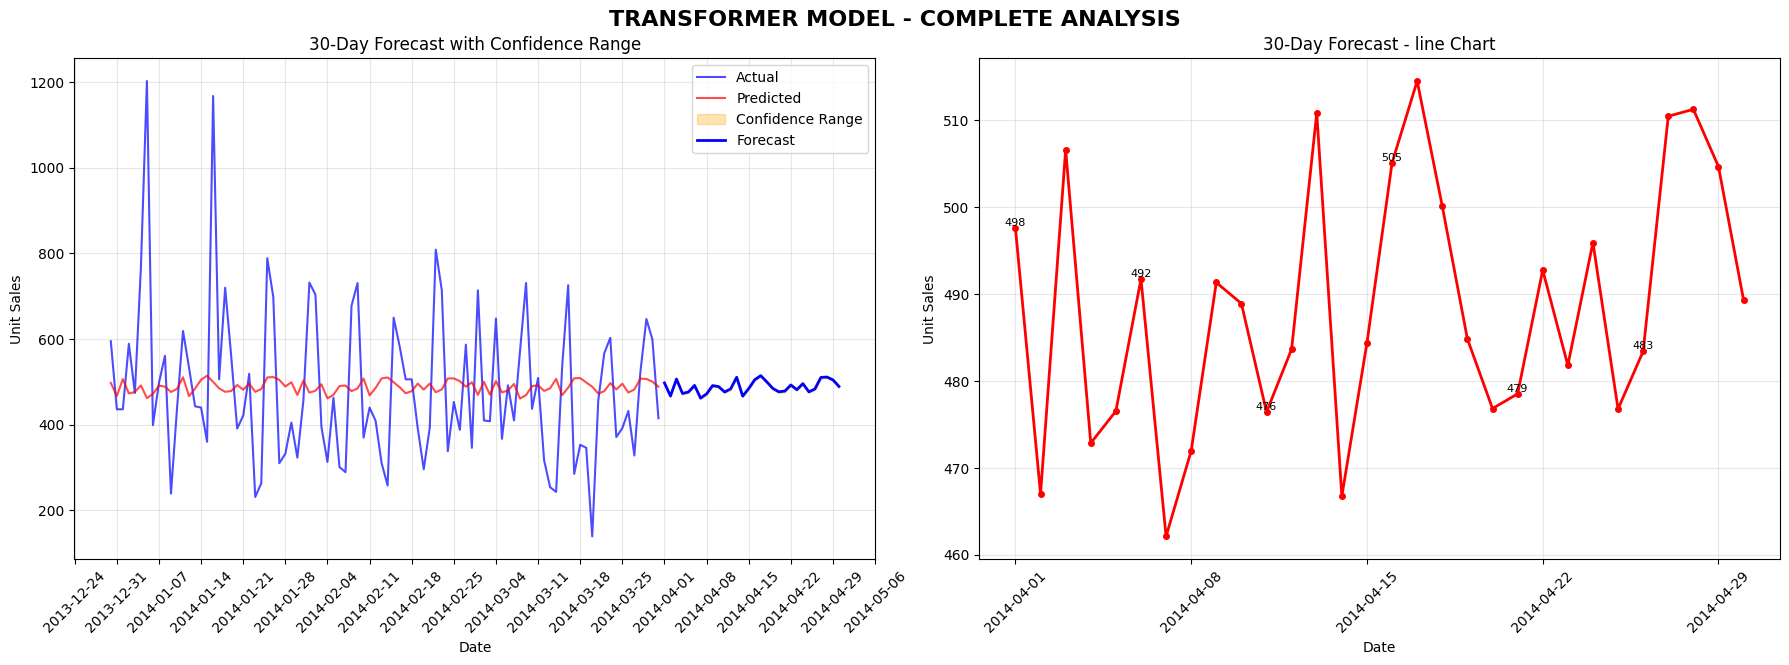


📋 30-DAY FORECAST VALUES
Day    Date         Forecast     Change      
------------------------------------------------------------
Day 1    2014-04-01     497.59   ◆    0.00
Day 2    2014-04-02     467.00   ▼  -30.60
Day 3    2014-04-03     506.64   ▲   39.64
Day 4    2014-04-04     472.86   ▼  -33.78
Day 5    2014-04-05     476.54   ▲    3.68
Day 6    2014-04-06     491.76   ▲   15.22
Day 7    2014-04-07     462.12   ▼  -29.64
Day 8    2014-04-08     471.98   ▲    9.86
Day 9    2014-04-09     491.35   ▲   19.37
Day 10   2014-04-10     488.92   ▼   -2.43
Day 11   2014-04-11     476.44   ▼  -12.48
Day 12   2014-04-12     483.68   ▲    7.24
Day 13   2014-04-13     510.86   ▲   27.18
Day 14   2014-04-14     466.75   ▼  -44.11
Day 15   2014-04-15     484.40   ▲   17.65
Day 16   2014-04-16     505.12   ▲   20.72
Day 17   2014-04-17     514.54   ▲    9.42
Day 18   2014-04-18     500.13   ▼  -14.41
Day 19   2014-04-19     484.86   ▼  -15.27
Day 20   2014-04-20     476.84   ▼   -8.01
Day 21 

In [2]:
# TRANSFORMER MODEL
# ============================================
from darts import TimeSeries
from darts.models import TransformerModel
from darts.dataprocessing.transformers import Scaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("TRANSFORMER MODEL FOR TIME SERIES FORECASTING")
print("="*60)

# ============================================
# 1. DATA PREPARATION WITH PROPER DATES
# ============================================
print("\n📊 STEP 1: Preparing Data...")

# Check if df has a date column
if 'date' in df.columns:
    # Create time series with explicit date column
    series = TimeSeries.from_dataframe(df, time_col='date', value_cols='unit_sales')
    print(f"   ✓ Time series created with {len(series)} points")
    print(f"   ✓ Date range: {series.start_time()} to {series.end_time()}")
else:
    # If no date column, create proper datetime index
    print("   ⚠ No date column found. Creating datetime index...")
    start_date = pd.Timestamp('2013-01-02')
    dates = pd.date_range(start=start_date, periods=len(df), freq='D')
    df_with_dates = df.copy()
    df_with_dates['date'] = dates
    series = TimeSeries.from_dataframe(df_with_dates, time_col='date', value_cols='unit_sales')
    print(f"   ✓ Time series created with {len(series)} points")
    print(f"   ✓ Date range: {series.start_time()} to {series.end_time()}")

scaler = Scaler()
scaled_series = scaler.fit_transform(series)

# Split into train and validation (80-20)
train, val = scaled_series.split_before(0.8)
print(f"   ✓ Training set: {len(train)} points ({train.start_time()} to {train.end_time()})")
print(f"   ✓ Validation set: {len(val)} points ({val.start_time()} to {val.end_time()})")

# ============================================
# 2. MODEL CREATION
# ============================================
print("\n STEP 2: Creating Transformer Model...")
model = TransformerModel(
    input_chunk_length=30,
    output_chunk_length=30,
    d_model=32,
    nhead=4,
    num_encoder_layers=2,
    num_decoder_layers=2,
    dim_feedforward=128,
    dropout=0.1,
    n_epochs=50,
    batch_size=32,
    optimizer_kwargs={'lr': 1e-4},
    random_state=42
)
print("   ✓ Model created successfully")

# ============================================
# 3. MODEL TRAINING
# ============================================
print("\n STEP 3: Training Model (this may take a few minutes)...")
model.fit(train, val_series=val, verbose=True)
print("   ✓ Model training complete!")

# ============================================
# 4. MODEL EVALUATION
# ============================================
print("\n STEP 4: Evaluating Model...")
pred_scaled = model.predict(n=len(val))
pred = scaler.inverse_transform(pred_scaled)
actual = scaler.inverse_transform(val)

y_pred = pred.values().flatten()
y_actual = actual.values().flatten()

mae = mean_absolute_error(y_actual, y_pred)
rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
print(f"   ✓ MAE: {mae:.2f}")
print(f"   ✓ RMSE: {rmse:.2f}")

# ============================================
# 5. GENERATE 30-DAY FORECAST
# ============================================
print("\n STEP 5: Generating 30-Day Forecast...")
forecast_scaled = model.predict(n=30)
forecast = scaler.inverse_transform(forecast_scaled)
forecast_values = forecast.values().flatten()

# Get forecast dates properly from the TimeSeries object
last_date = series.end_time()
forecast_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=30, freq='D')
print(f"   ✓ Forecast period: {forecast_dates[0].strftime('%Y-%m-%d')} to {forecast_dates[-1].strftime('%Y-%m-%d')}")

# ============================================
# 6. VISUALIZATION - ALL GRAPHS WITH PROPER DATES
# ============================================
print("\n STEP 6: Creating Visualizations...")

# Get date indices for plotting
historical_dates = series.time_index
val_dates = val.time_index

plt.figure(figsize=(18, 12))

# Graph 1: Actual vs Predicted (Line Plot with dates)
plt.subplot(2, 2, 1)
plt.plot(val_dates[-200:], y_actual[-200:], label='Actual', color='blue', linewidth=1.5, alpha=0.7)
plt.plot(val_dates[-200:], y_pred[-200:], label='Predicted', color='red', linewidth=1.5, alpha=0.7)
plt.title('Actual vs Predicted (Last 200 Validation Points)', fontsize=12)
plt.xlabel('Date')
plt.ylabel('Unit Sales')
plt.legend()
plt.grid(True, alpha=0.3)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.xticks(rotation=45)


# Graph 3: 30-Day Forecast (line Chart with dates)
plt.subplot(2, 2, 2)
plt.plot(forecast_dates, forecast_values, 'ro-', linewidth=2, markersize=4)
plt.title('30-Day Forecast - line Chart', fontsize=12)
plt.xlabel('Date')
plt.ylabel('Unit Sales')
plt.grid(True, alpha=0.3)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.gca().xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
plt.xticks(rotation=45)
for i, (date, val) in enumerate(zip(forecast_dates, forecast_values)):
    if i % 5 == 0:  # Label every 5th day
        plt.text(date, val, f'{val:.0f}', ha='center', va='bottom', fontsize=8)


# Graph 6: Forecast with confidence (simulated confidence intervals)
plt.subplot(2, 2, 1)
# Simulate confidence intervals (since darts doesn't provide them directly)
std_dev = forecast_values.std() * 0.2
upper = forecast_values + std_dev
lower = forecast_values - std_dev

plt.fill_between(forecast_dates, lower, upper, alpha=0.3, color='orange', label='Confidence Range')
plt.plot(forecast_dates, forecast_values, 'b-', linewidth=2, label='Forecast')
plt.title('30-Day Forecast with Confidence Range', fontsize=12)
plt.xlabel('Date')
plt.ylabel('Unit Sales')
plt.legend()
plt.grid(True, alpha=0.3)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.gca().xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
plt.xticks(rotation=45)

plt.suptitle('TRANSFORMER MODEL - COMPLETE ANALYSIS', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================
# 7. PRINT FORECAST VALUES WITH DATES
# ============================================
print("\n" + "="*70)
print("📋 30-DAY FORECAST VALUES")
print("="*70)
print(f"{'Day':<6} {'Date':<12} {'Forecast':<12} {'Change':<12}")
print("-"*60)
prev = forecast_values[0]
for i, (date, val) in enumerate(zip(forecast_dates, forecast_values), 1):
    change = val - prev if i > 1 else 0
    change_symbol = "▲" if change > 0 else "▼" if change < 0 else "◆"
    date_str = date.strftime('%Y-%m-%d')
    print(f"Day {i:<2}   {date_str}   {val:>8.2f}   {change_symbol} {change:>7.2f}")
    prev = val




Temporal Transformer

In [ ]:
import numpy as np
import pandas as pd
from darts import TimeSeries
from darts.models import TransformerModel
from darts.dataprocessing.transformers import Scaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import mlflow
import pickle

# ============================================
# 1. PREPARE DATA FOR DARTS TRANSFORMER
# ============================================
# Convert to Darts TimeSeries
series = TimeSeries.from_series(df['unit_sales'])

# Scale the data
scaler = Scaler()
scaled_series = scaler.fit_transform(series)

# Split into train and validation (80-20)
train, val = scaled_series.split_before(0.8)

# ============================================
# 2. BUILD TRANSFORMER MODEL
# ============================================
transformer_model = TransformerModel(
    input_chunk_length=36,  # Look back 36 time steps [citation:7]
    output_chunk_length=12,  # Predict next 12 steps
    d_model=32,  # Dimension of transformer internal representation
    nhead=4,  # Number of attention heads
    num_encoder_layers=2,  # Number of encoder layers
    num_decoder_layers=2,  # Number of decoder layers
    dim_feedforward=128,  # Feedforward network dimension
    dropout=0.2,  # Dropout rate
    activation='gelu',  # Activation function
    batch_size=32,
    n_epochs=100,
    optimizer_kwargs={'lr': 1e-4},
    random_state=42
)

# ============================================
# 3. TRAIN TRANSFORMER
# ============================================
transformer_model.fit(
    series=train,
    val_series=val,
    verbose=True
)

# ============================================
# 4. MAKE PREDICTIONS
# ============================================
# Predict on validation set
pred_scaled = transformer_model.predict(n=len(val))
pred = scaler.inverse_transform(pred_scaled)
actual = scaler.inverse_transform(val)

# Convert to numpy for metrics
y_pred = pred.values().flatten()
y_actual = actual.values().flatten()

# Calculate metrics
transformer_mae = mean_absolute_error(y_actual, y_pred)
transformer_rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
print(f"Transformer - MAE: {transformer_mae:.2f}, RMSE: {transformer_rmse:.2f}")

# ============================================
# 5. SAVE TO MLFLOW
# ============================================
with mlflow.start_run(run_name="Transformer_Model"):
    mlflow.log_param("model_type", "Transformer")
    mlflow.log_param("input_chunk_length", 36)
    mlflow.log_param("output_chunk_length", 12)
    mlflow.log_param("d_model", 32)
    mlflow.log_param("nhead", 4)
    mlflow.log_param("num_layers", "2-2")
    mlflow.log_param("dropout", 0.2)
    mlflow.log_param("epochs", 100)
    mlflow.log_metric("mae", transformer_mae)
    mlflow.log_metric("rmse", transformer_rmse)

    # Save model
    transformer_model.save("transformer_model.pkl")
    mlflow.log_artifact("transformer_model.pkl")

    # Save scaler
    with open("transformer_scaler.pkl", "wb") as f:
        pickle.dump(scaler, f)
    mlflow.log_artifact("transformer_scaler.pkl")

In [ ]:
import pandas as pd
from darts import TimeSeries
from darts.models import TransformerModel
from darts.dataprocessing.transformers import Scaler
from sklearn.metrics import mean_absolute_error


# 2. Ensure date format and set Darts series
df['date'] = pd.to_datetime(df['date'])
series = TimeSeries.from_dataframe(df, time_col='date', value_cols='unit_sales', freq='D')

# 3. Scale the data
scaler = Scaler()
scaled_series = scaler.fit_transform(series)

# 4. DEFINE TUNING PARAMETERS
parameters = {
    'input_chunk_length': [24, 36],
    'output_chunk_length': [12],
    'd_model': [16, 32],
    'n_epochs': [20] # Low epochs for a quick test run
}

# 5. START TUNING
print("Data reloaded. Starting Grid Search...")
best_model, best_params, best_score = TransformerModel.gridsearch(
    parameters=parameters,
    series=scaled_series,
    start=0.8,
    forecast_horizon=12,
    metric=mean_absolute_error,
    verbose=False
)

print(f"\nWINNER! Best Params: {best_params}")
print(f"Best MAE: {best_score:.4f}")

